{'fed_funds_rate': 'Fed Funds Rate', 'yield_2y': '2Y Treasury Yield', 'yield_10y': '10Y Treasury Yield', 'dxy': 'DXY (Dollar Index)', 'sp500': 'S&P 500', 'mortgage_30y': 'Mortgage 30Y'}


C:\Users\wjian\AppData\Local\Temp\ipykernel_53756\2287704410.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


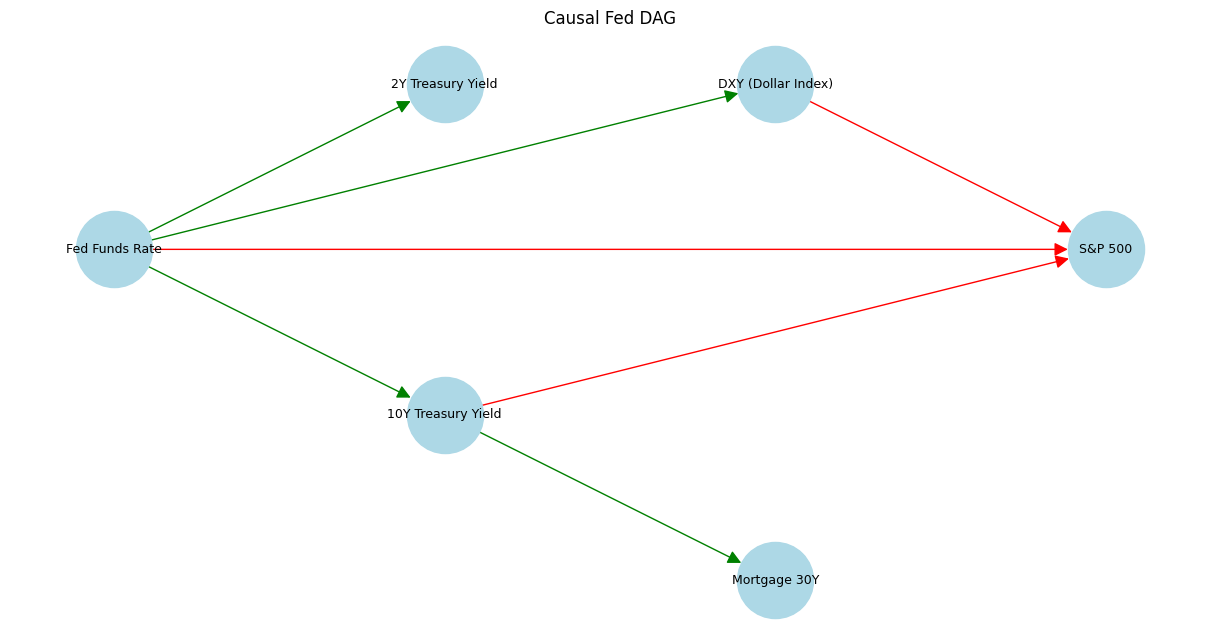

In [ ]:
import json
import networkx as nx
import matplotlib.pyplot as plt

with open("data/dag.json") as f:
    dag = json.load(f)

G = nx.DiGraph()
for node in dag["nodes"]:
    G.add_node(node["id"], label=node["label"])
for edge in dag["edges"]:
    G.add_edge(edge["from"], edge["to"], sign=edge["sign"])

# Manual positions based on layer
pos = {
    "fed_funds_rate": (0, 0),
    "yield_2y":       (1, 1),
    "yield_10y":      (1, -1),
    "dxy":            (2, 1),
    "sp500":          (3, 0),
    "mortgage_30y":   (2, -2),
}

labels = {node["id"]: node["label"] for node in dag["nodes"]}
edge_colors = ["green" if e["sign"] == "+" else "red" for e in dag["edges"]]

plt.figure(figsize=(12, 6))
nx.draw(G, pos=pos, labels=labels, edge_color=edge_colors,
        with_labels=True, node_size=3000,
        node_color="lightblue", arrows=True,
        arrowsize=20, font_size=9)

plt.title("Causal Fed DAG")
plt.tight_layout()
plt.show()